# 3) Final Prediction

Results for our predictors:

- **mean** :
  - *sqrt(Mean Square Error)* : 61.47 Millions
  - *R²* : -1.18
- **linear regression** :
  - *sqrt(Mean Square Error)* : 61.39 Millions
  - *R²* : 0.38
- **MLP regression** : 
  - *sqrt(Mean Square Error)* : 87.34 Millions
  - *R²* : 0.19 <br>
(! changes a little bit at every execution)
- **KNN regression** : 
  - *sqrt(Mean Square Error)* : 54.3 Millions
  - *R²* : 0.55
- **SVR rbf** : 
  - *sqrt(Mean Square Error)* : 48.13 Millions
  - *R²* : 0.58

For our final predictor we choose **KNN Regression** to be our method. <br>
- Even if it is not the most efficient now (best R² but not the best MSE), it is the one who has the better chance of improving the result with more data 

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import timeit
import warnings
warnings.filterwarnings("ignore")

## 0) Load 

In [36]:
def loadData():
    # title,img_url,description,ratings,n_votes,is_adult,production_year,runtime,genres,release_year,studio,img_embeddings,text_embeddings

    X1 = pd.read_csv("X1.csv")
    X2 = pd.read_csv("X2.csv")
    Y1 = pd.read_csv("Y1.csv", header=None, names=['revenue'])

    split = X1['genres'].str.split(',')
    X1['genres']=split
    split = X2['genres'].str.split(',')
    X2['genres']=split


    X1["img_embeddings_array"] =  [ast.literal_eval(X1['img_embeddings'][i]) for i in range(len(X1))]
    X1["text_embeddings_array"] = [ast.literal_eval(X1['text_embeddings'][i]) for i in range(len(X1))]

    X2 ["img_embeddings_array"] =  [ast.literal_eval(X2['img_embeddings'][i]) for i in range(len(X2))]
    X2 ["text_embeddings_array"] = [ast.literal_eval(X2['text_embeddings'][i]) for i in range(len(X2))]


    Y1["log_revenue"] = np.log(Y1["revenue"])

    X1["exp_ratings"] = np.exp(X1["ratings"])
    X1["log_ratings"] = np.log(X1["ratings"])
    X1["log_n_votes"] = np.log(X1["n_votes"])

    X2["exp_ratings"] = np.exp(X2["ratings"])
    X2["log_ratings"] = np.log(X2["ratings"])
    X2["log_n_votes"] = np.log(X2["n_votes"])


    # gèrer les genres

    list_genres = np.unique(np.concatenate(X1['genres']))


    for genre in list_genres:
        X1[genre] = [int(genre in X1['genres'][i]) for i in range(len(X1['genres']))]

    for genre in list_genres:
        X2[genre] = [int(genre in X2['genres'][i]) for i in range(len(X2['genres']))]


    liste_variables = []
    for genre in list_genres:
        a = np.sum(X1[genre])
        liste_variables.append(a)


    dic = {}
    j = 0
    for genre in list_genres:
        dic[genre] = liste_variables[j]
        j+=1


    X1['genre'] = [sum([dic[i]for i in j])/len(j) for j in X1['genres']]
    X2['genre'] = [sum([dic[i]for i in j])/len(j) for j in X2['genres']]

    list_genres = ['genre'] + list(list_genres) 



    # gèrer les studios


    X_dum = pd.get_dummies(X1['studio'])

    liste_variables = []
    for i in X_dum:
        a = np.sum(X_dum[i])
        liste_variables.append(a)


    dic = {}
    j = 0
    for i in X_dum:
        dic[i] = liste_variables[j]
        j+=1



    X1['std'] = [dic[i] for i in X1['studio']]
    X2['std'] = [dic[i] if i in dic else 1 for i in X2['studio']]



    # gèrer img embeddigs

    A = list(X1["img_embeddings_array"].copy())
    A = np.asarray(A)

    B = list(X2["img_embeddings_array"].copy())
    B = np.asarray(B)

    U , S, Vt = np.linalg.svd(A)
    nb_compo_img = len(S)

    for i in range(len(S)):
        X1["img"+str(i)] = U[::][i]*S[i]
        X2["img"+str(i)] =B@Vt[i]



    # gèrer text embeddigs

    A = list(X1["text_embeddings_array"].copy())
    A = np.asarray(A)


    B = list(X2["text_embeddings_array"].copy())
    B = np.asarray(B)

    U, S, Vt = np.linalg.svd(A)
    nb_compo_text = len(S)

    for i in range(len(S)):
        X1["text"+str(i)] =U[::][i] *S[i]
        X2["text"+str(i)] = B@Vt[i]





    genre = list_genres


    img = list(np.array(range(nb_compo_img), str))
    for i in range(len(img)):
        img[i] = "img"+img[i]


    text = list(np.array(range(nb_compo_text), str))
    for i in range(len(text)):
        text[i] = "text"+text[i]


    variable_base = ["exp_ratings", "ratings", "log_ratings",  "n_votes", "log_n_votes",  "production_year", "release_year", "std", 'genre', "runtime" ] 
    variables_svd =  img + text
    variable_genre = genre
    liste_variables = variable_base+variables_svd+variable_genre
    liste_targets = [ "log_revenue", "revenue"]


    X1 = X1[liste_variables]
    Y1 = Y1[liste_targets]

    X2 = X2[liste_variables] 

    return X1, Y1, variable_base, variables_svd, variable_genre , liste_targets, X2

In [37]:
X, y, variable_base, variables_svd, variable_genre, liste_targets, X2 = loadData()
print(X.shape)
print(X2.shape)

(3540, 2854)
(1518, 2854)


**Checking the SVD of image embeddings for X1 and X2**

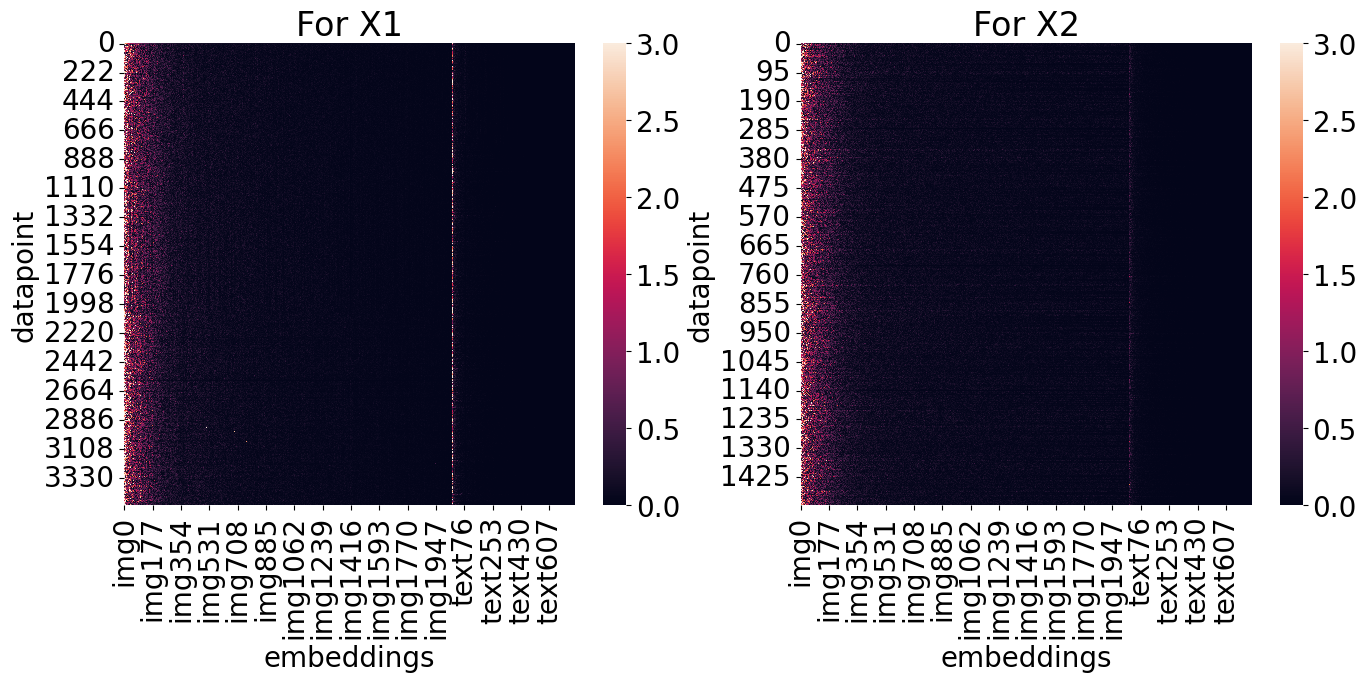

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))
sns.heatmap(np.abs(X[variables_svd]), vmin=0, vmax=3, ax=ax1)
ax1.set_ylabel("datapoint")
ax1.set_xlabel("embeddings")
ax1.set_title("For X1")
sns.heatmap(np.abs(X2[variables_svd]), vmin=0, vmax=3, ax=ax2)
ax2.set_ylabel("datapoint")
ax2.set_xlabel("embeddings")
ax2.set_title("For X2")
plt.show()

## 1. Clean Data

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, train_size=0.9)

In [40]:
# We remove features that are too small and those where the data are too noisy
EPS = 100

selected_svd = []

for var in variables_svd:
    if np.sum(np.abs(X_train[var])) < EPS:
        X_train.drop(var, axis=1, inplace=True)
        X_test.drop(var, axis=1, inplace=True)
        X2.drop(var, axis=1, inplace=True)
        
    else :
        selected_svd.append(var)

In [41]:
# In runtime : replace //N with mean substitution

Rt_train = X_train['runtime']
nbNan =0

for ind in Rt_train.index:
    value = Rt_train[ind]
    nbNan += (value=='\\N')
    if( value=='\\N'):
        Rt_train = Rt_train.drop(ind)

print("The percentage of /N in runtime is : ", (nbNan/len(X_train))*100)
mean = np.mean(np.array(Rt_train, dtype=float))
print("Runtime average is (in minutes)", mean)



Rt_train = X_train['runtime']
for ind in Rt_train.index:
    if( Rt_train[ind]=='\\N'):
        Rt_train[ind] = mean

Rt_test = X_test['runtime']
for ind in Rt_test.index:
    if( Rt_test[ind]=='\\N'):
        Rt_test[ind] = mean

Rt2_test = X2['runtime']
for ind in Rt2_test.index:
    if( Rt2_test[ind]=='\\N'):
        Rt2_test[ind] = mean


Rt_train = pd.DataFrame(Rt_train, dtype=float)
Rt_test = pd.DataFrame(Rt_test, dtype=float)

Rt2_test = pd.DataFrame(Rt2_test, dtype=float)


X_train['runtime']=Rt_train
X_train['log_runtime'] = np.log(Rt_train)

X_test['runtime']=Rt_test
X_test['log_runtime'] = np.log(Rt_test)

X2['runtime']=Rt2_test
X2['log_runtime'] = np.log(Rt2_test)

The percentage of /N in runtime is :  7.689893283113622
Runtime average is (in minutes) 91.9534172050323


## 2. Tuning

In [42]:
X_train_tun, X_test_tun, y_train_tun, y_test_tun = train_test_split(X_train, y_train, random_state=42)


In [43]:
dic_y_train =  {}
dic_y_test = {}


dic_y_train["revenue"] = y_train_tun["revenue"]
dic_y_test["revenue"] = y_test_tun["revenue"]

dic_y_train["log_revenue"] = y_train_tun["log_revenue"]
dic_y_test["log_revenue"] = y_test_tun["log_revenue"]


In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train_tun)
X_train_tun = scaler.transform(X_train_tun)
X_test_tun = scaler.transform(X_test_tun)



In [45]:
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from matplotlib import pyplot
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.neural_network import MLPRegressor
from sklearn import metrics
import sklearn
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.neighbors import KNeighborsRegressor

def Mutual_info(X_train, y_train, X_test, k):
    # configure to select all features
    fs = SelectKBest(mutual_info_regression, k=k)
    # learn relationship from training data
    fs.fit(X_train, np.ravel(y_train))
    # transform train input data
    X_train_nonlin = fs.transform(X_train)
    # transform test input data
    X_test_nonlin = fs.transform(X_test)
    
    fs = SelectKBest(mutual_info_regression, k=k)
    fs.fit(X_train_nonlin, np.ravel(y_train))

    return X_train_nonlin, X_test_nonlin, fs


def get_error(method, param, X_train, X_test, y_train, y_test, logy:bool):
    method = sklearn.base.clone(method)
    method.set_params(**param)
    method.fit(X_train, y_train)
    y_pred = method.predict(X_test)
    if logy:
        error = np.sqrt(mean_squared_error(np.exp(y_test),np.exp(y_pred)))
    else:
        error = np.sqrt(mean_squared_error(y_test,y_pred))
    return error



def evalParam(method, list_params, list_nb_features, X_train, X_test,  y_train, y_test, logy:bool):
    list_errors = [[] for j in range(len(list_nb_features))]


    for nb_features_index in range(len(list_nb_features)):
        

        X_train, X_test, _ =  Mutual_info(X_train, y_train, X_test, list_nb_features[nb_features_index])

        for p in range(len(list_params)):
            # print(str(int(logy))+"/1 & "+str(nb_features_index)+"/"+str(len(list_nb_features)+1)+ " & "+ str(p)+"/"+str(len(list_params)+1))            
            error = get_error(method, list_params[p], X_train, X_test, y_train, y_test, logy)
            list_errors[nb_features_index].append(error)
    
    return list_errors

    
def evalParam_and_y(method, list_params, list_nb_features, X_train, X_test, dic_y_train, dic_y_test):
    print("y")    
    errors_y = evalParam(method, list_params, list_nb_features, X_train, X_test, dic_y_train['revenue'], dic_y_test['revenue'], False)
    print("log_y")
    errors_log_y = evalParam(method, list_params, list_nb_features, X_train, X_test, dic_y_train['log_revenue'], dic_y_test['log_revenue'], True)

    return [errors_y, errors_log_y]
    





### Iterations to find the best parameters

In [46]:
# first tuning 


# from sklearn.neighbors import KNeighborsRegressor

# KNN=KNeighborsRegressor()
# paramKNN=[{"n_neighbors":i ,"weights":j,"p":p}  for i in  [1, 5, 10, 20, 50, 100, 200, 500] for j in ("uniform","distance")  for p in (1,2)] 
# list_nb_features = [X_test_tun.shape[1], 1000, 500, 200, 100, 50, 20, 10, 5, 2]


# errors = evalParam_and_y(KNN, paramKNN, list_nb_features, X_train_tun, X_test_tun, dic_y_train, dic_y_test)




# second tuning 


# from sklearn.neighbors import KNeighborsRegressor

# KNN=KNeighborsRegressor()
# paramKNN=[{"n_neighbors":i ,"weights":j,"p":p}  for i in  [1, 2, 3, 4, 5, 10, 15, 20, 30, 40, 50] for j in ("uniform","distance")  for p in (1,2)] 
# list_nb_features = [50, 20, 10, 5, 2]


# errors = evalParam_and_y(KNN, paramKNN, list_nb_features, X_train_tun, X_test_tun, dic_y_train, dic_y_test)




In [47]:
# from sklearn.neighbors import KNeighborsRegressor

# KNN=KNeighborsRegressor()
# paramKNN=[{"n_neighbors":50-i ,"weights":j,"p":p}  for i in  range(49) for j in ("uniform","distance")  for p in (1,2)] 
# list_nb_features = [50-i for i in range(49)]


# errors = evalParam_and_y(KNN, paramKNN, list_nb_features, X_train_tun, X_test_tun, dic_y_train, dic_y_test)

In [48]:
# # Revenue
# errors_list = np.array(errors[0])

# # "uniform" "distance"
# weights = "uniform"
# # 1, 2
# p = 1

# errors_list_XX = [[errors_list[i][j] for j in range(len(errors_list[i])) if  ((paramKNN[j]['weights'] == weights) and (paramKNN[j]['p'] == p) ) ] for i in range(len(errors_list))]
# errors_list_XX = np.array(errors_list_XX)

# print(errors_list_XX.shape)




# fig = plt.figure(figsize=(25,20), facecolor="w")
# sns.heatmap(np.array(errors_list_XX)/1000000,  vmin=0, vmax=100, fmt='.2g', xticklabels=[ i["n_neighbors"] for i in paramKNN if ((i["weights"] == weights)and(i['p'] == p))], yticklabels=list_nb_features, annot=True)

# plt.xlabel("parameters KNN")
# plt.ylabel("nb features")
# plt.title("Mean square error of KNN trained with revenue, weights are "+str(weights)+" and distance is "+str(p)+" (1=manhattan, 2=euclidean)")
# # fig.add_axes(ax)
# plt.show()


### Plots to vilualize the effect of the tuning

In [49]:
# # log revenue
# errors_list = np.array(errors[1])

# # "uniform" "distance"
# weights = "uniform"
# # 1, 2
# p = 1

# errors_list_XX = [[errors_list[i][j] for j in range(len(errors_list[i])) if  ((paramKNN[j]['weights'] == weights) and (paramKNN[j]['p'] == p) ) ] for i in range(len(errors_list))]
# errors_list_XX = np.array(errors_list_XX)

# print(errors_list_XX.shape)




# fig = plt.figure(figsize=(25,20), facecolor="w")
# sns.heatmap(np.array(errors_list_XX)/1000000,  vmin=0, vmax=100, fmt='.2g', xticklabels=[ i["n_neighbors"] for i in paramKNN if ((i["weights"] == weights)and(i['p'] == p))], yticklabels=list_nb_features, annot=True)

# plt.xlabel("parameters KNN")
# plt.ylabel("nb features")
# plt.title("Mean square error of KNN trained with log revenue, weights are "+str(weights)+" and distance is "+str(p)+" (1=manhattan, 2=euclidean)")
# # fig.add_axes(ax)
# plt.show()


### find best parameters after tuning

In [50]:
# er = np.array(errors).copy()

In [51]:
# minimum = er.min()
# for i in range(len(er)):
#     for j in range(len(er[i])):
#         for k in range(len(er[i][j])):
#             if (er[i][j][k]) == minimum:
#                 ib = i
#                 jb = j
#                 kb = k
#                 print(er[ib][jb][kb])
#                 print(i)
#                 print(list_nb_features[j])
#                 print(paramKNN[k])                
#                 # er[i][j][k] = er[i][j][k]*2

MSE = 44003823.06792077 <br>
log_revenue<br>
nb_features = 10<br>
{'n_neighbors': 11, 'weights': 'distance', 'p': 1}

In [52]:
def Mutual_info(X_train, y_train, X_test, k):
    # configure to select all features
    fs = SelectKBest(mutual_info_regression, k=k)
    # learn relationship from training data
    fs.fit(X_train, np.ravel(y_train))
    # transform train input data
    X_train_nonlin = fs.transform(X_train)
    # transform test input data
    X_test_nonlin = fs.transform(X_test)
    
    fs = SelectKBest(mutual_info_regression, k=k)
    fs.fit(X_train_nonlin, np.ravel(y_train))

    return X_train_nonlin, X_test_nonlin, fs


X_train_selected, X_test_selected, _ = Mutual_info(X_train_tun , y_train_tun['revenue'], X_test_tun, 10)

selected_features = np.zeros(10)
EPS = 0


for i in range(len(X_train_selected.T)):
    col1 = X_train_selected.T[i]
    for j in range(len(X_train_tun.T)):
        col2 = X_train_tun.T[j]
        # for j in range(len(np.array(X_train).T)):
        #     col2 = np.array(X_train).T[j]
        if (np.abs(np.sum(np.abs(col1-col2))))<=EPS:
            selected_features[i] = int(j)
            # print(np.abs(np.sum(np.abs(col1-col2))))
            break

print(selected_features)


[1.000e+00 3.000e+00 4.000e+00 5.000e+00 6.000e+00 7.000e+00 8.000e+00
 9.000e+00 8.000e+00 1.707e+03]


In [53]:
# [   3.    4.    5.    6.    7.    8.    9. 1611.    8. 1713.]

# X_test_KNN = X_test[[X_test.columns[int(i)] for i in selected_features]]

liste = [X_train.columns[int(i)] for i in selected_features]
print(liste)
liste = np.unique(liste)
X_train_KNN = X_train[liste]
X_test_KNN = X_test[liste]

X2_KNN = X2[liste]



['ratings', 'n_votes', 'log_n_votes', 'production_year', 'release_year', 'std', 'genre', 'runtime', 'genre', 'log_runtime']


In [54]:
print(X2_KNN.shape)
print(X_test_KNN.shape)


(1518, 10)
(354, 10)


## 3. Final Prediction


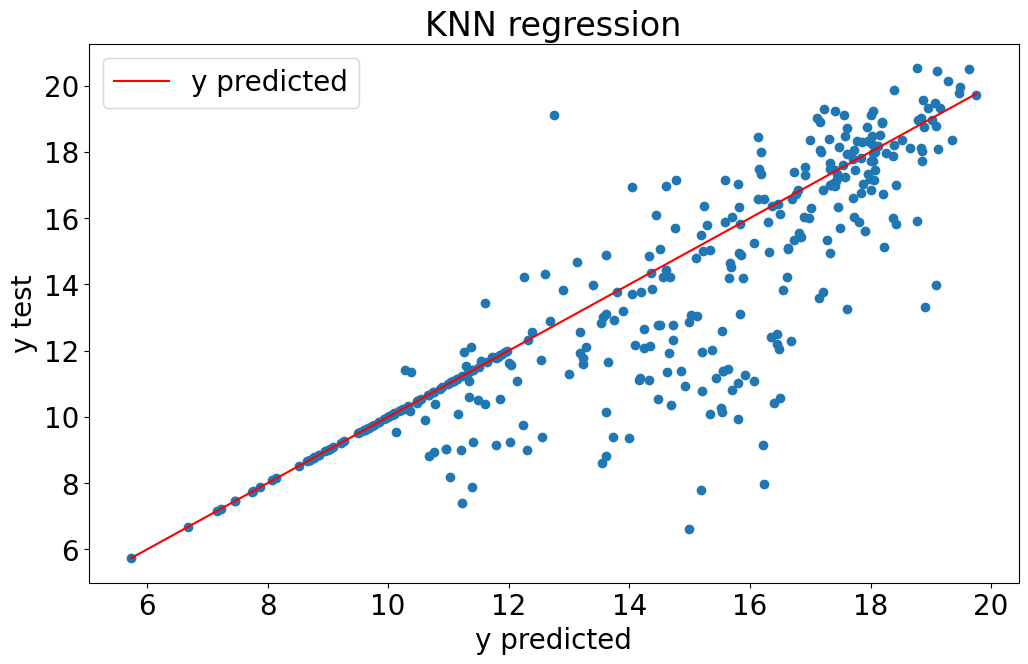

Mean square error in millions : 71.33512831932174
R squared score:  0.4896814496953058


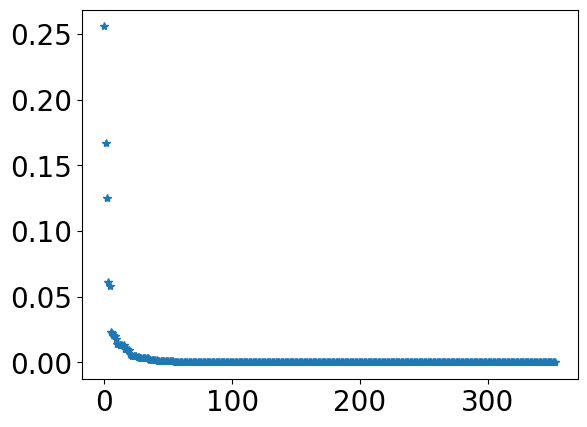

In [55]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
scaler.fit(X_train_KNN)
X_train_KNN = scaler.transform(X_train_KNN)
X_test_KNN = scaler.transform(X_test_KNN)
X2_KNN = scaler.transform(X2_KNN)



y_train_KNN = y_train['revenue']
y_test_KNN = y_test['revenue']


best_nb_features = 10
knn_regressor = KNeighborsRegressor(n_neighbors = 11, weights= 'distance', p=1)


knn_regressor.fit(X_train_KNN, y_train_KNN)
y_predict = knn_regressor.predict(X_test_KNN)

ly_predict = np.log(y_predict)
y_test_KNN = np.log(y_test_KNN)

plt.rc("font", size=20)
plt.figure(figsize=(12,7))
plt.title('KNN regression')
plt.xlabel("y predicted")
plt.ylabel("y test")
plt.plot(ly_predict,y_test_KNN,'o')
plt.plot(np.linspace(np.min(ly_predict),np.max(ly_predict),2),np.linspace(np.min(ly_predict),np.max(ly_predict),2), label="y predicted", color="red")
plt.legend()

y_test1= np.exp(y_test_KNN)
y_predict1 = (y_predict)
y_predict2 = knn_regressor.predict(X2_KNN)


plt.show()

vec = (y_test1-y_predict1)**2
vec = vec/sum(vec)
vec = sorted(vec, reverse=True)
plt.plot(range(len(vec)), vec, "*")

print("Mean square error in millions :", np.sqrt(mean_squared_error(y_test1,y_predict1))/1000000)
print("R squared score: ",knn_regressor.score(X_test_KNN, np.exp(y_test_KNN)))


error_prediciton = np.sqrt(mean_squared_error(y_test1,y_predict1)) 


In [56]:
print(X_test.shape)
print(X2.shape)
print(y_predict2.shape)
print(y_predict.shape)



(354, 1708)
(1518, 1708)
(1518,)
(354,)


**Comparison of Y1 predicted and Y2 predicted.**
**We compare in logarithm**

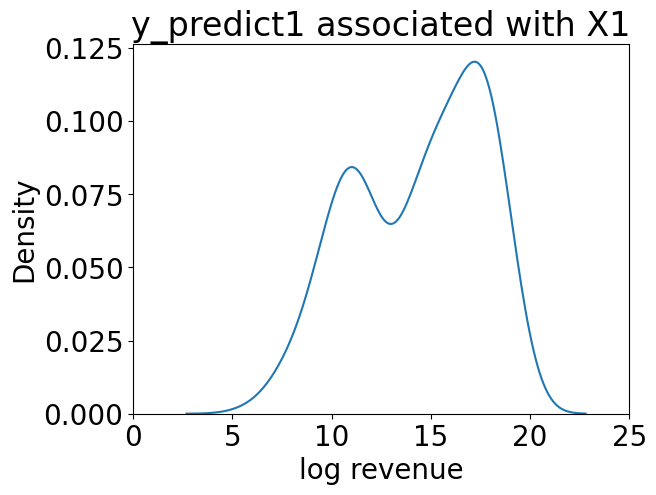

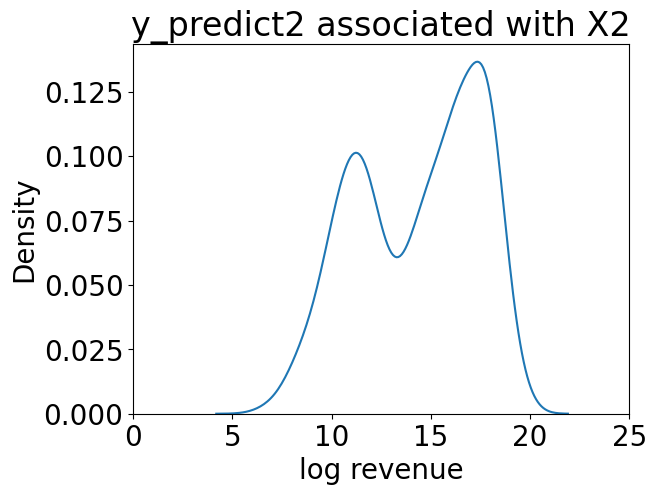

In [57]:
sns.kdeplot(np.log(y_predict1))
plt.title("y_predict1 associated with X1")
plt.xlabel( "log revenue")
plt.xlim([0, 25])
plt.show()

sns.kdeplot(np.log(y_predict2))
plt.title("y_predict2 associated with X2")
plt.xlabel( "log revenue")
plt.xlim([0, 25])
plt.show()

In [58]:
index_max = np.argmax(y_predict)
maxi = y_predict[index_max]
small = 0
medium = 0
big = 0
very_big = 0
total = 354
for row in y_predict:
    if row< 5:
        petit = petit+1
    if row>= 5 and row<10:
        medium = medium+1
    if row>=10 and row<15:
        big = big+1
    if row>=15:
        very_big = very_big+1
print("For Y1 predicted \n Pourcentage de small : ", (small/total)*100, "medium : ", (medium/total)*100, "big : ", (big/total)*100, "very big : ", (very_big/total)*100)
        

maxi = y_predict2[index_max]
small = 0
medium = 0
big = 0
very_big = 0
total = 1518
for row in y_predict2:
    if row< 5:
        petit = petit+1
    if row>= 5 and row<10:
        medium = medium+1
    if row>=10 and row<15:
        big = big+1
    if row>=15:
        very_big = very_big+1
print("For Y2 predicted \nPourcentage de small : ", (small/total)*100, "medium : ", (medium/total)*100, "big : ", (big/total)*100, "very big : ", (very_big/total)*100)
    

For Y1 predicted 
 Pourcentage de small :  0.0 medium :  0.0 big :  0.0 very big :  100.0
For Y2 predicted 
Pourcentage de small :  0.0 medium :  0.0 big :  0.0 very big :  100.0


**Creation of Y2**

In [59]:
file = open("Y2.csv", 'w')
for i in y_predict2:
    file.write(str(i)+"\n")
file.write(str(error_prediciton))
file.close()